# Markowitz Mean-Variance Optimisation

## Why this matters

Markowitz (1952) — the foundation of modern portfolio theory and the reason MV optimisation gets asked at every AM quant interview. The setup is simple:

> **Among all possible portfolios, find the weights that minimise variance for a given expected return — or maximise expected return for a given variance.**

The locus of solutions is the **efficient frontier**. The point on the frontier with the highest Sharpe ratio is the **tangency portfolio**.

You will be asked, in interview:
1. State the MV problem and write the Lagrangian.
2. Derive the **closed-form** solution for the unconstrained min-variance portfolio.
3. **Why is MV unstable** in practice? What's the "garbage-in garbage-out" problem with covariance estimation?
4. Tangency portfolio — what is it and why is it the "market portfolio" under CAPM?
5. **Constraints** — long-only, no shorting, sector limits — what do they cost?
6. Two assets: derive minimum-variance weights by hand.

This notebook covers all six on the BTC/ETH/SOL/BNB universe.

## The 30-second concept

Given $n$ assets with expected returns $\mu \in \mathbb{R}^n$ and covariance $\Sigma \in \mathbb{R}^{n \times n}$, the **portfolio** with weights $w \in \mathbb{R}^n$ ($\sum w_i = 1$) has:

$$\mu_p = w^T \mu, \qquad \sigma_p^2 = w^T \Sigma w$$

### Min-variance for target return $\mu^*$

$$\min_w \tfrac{1}{2} w^T \Sigma w \quad \text{s.t.} \quad w^T \mu = \mu^*, \; w^T \mathbf{1} = 1$$

Lagrangian gives the closed form (no other constraints):

$$w^* = \Sigma^{-1} \big[ \lambda_1 \mu + \lambda_2 \mathbf{1} \big]$$

with the multipliers solved from the two constraints. Plotting $\sigma_p$ vs $\mu_p$ traces a parabola — the **efficient frontier** is the upper half (you wouldn't accept lower return for the same risk).

### Tangency portfolio

If a risk-free rate $r_f$ exists, the tangency portfolio (highest Sharpe) is:

$$w_T = \frac{\Sigma^{-1}(\mu - r_f \mathbf{1})}{\mathbf{1}^T \Sigma^{-1}(\mu - r_f \mathbf{1})}$$

Under CAPM, the tangency portfolio = the **market portfolio**.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

df = pd.read_parquet('../../data/crypto_hourly.parquet')
df['ts'] = pd.to_datetime(df['ts'], utc=True)

# Daily log returns per symbol
daily = (df.set_index('ts')
         .groupby('symbol')['close']
         .resample('1D').last()
         .reset_index()
         .pivot(index='ts', columns='symbol', values='close')
         .dropna()
         .pipe(lambda d: np.log(d).diff().dropna()))

print(f'Universe: {daily.columns.tolist()}')
print(f'Sample:   {len(daily)} days, {daily.index[0].date()} → {daily.index[-1].date()}')

# Annualised summary stats
mu_ann = daily.mean() * 365
sigma_ann = daily.std() * np.sqrt(365)
corr = daily.corr()
cov_ann = daily.cov() * 365

print('\nAnnualised stats:')
print(pd.DataFrame({'μ': mu_ann, 'σ': sigma_ann}).round(3))
print('\nCorrelation matrix:')
print(corr.round(3))

Universe: ['BNB', 'BTC', 'ETH', 'SOL']
Sample:   730 days, 2024-04-20 → 2026-04-19

Annualised stats:
            μ      σ
symbol              
BNB     0.054  0.520
BTC     0.075  0.468
ETH    -0.148  0.710
SOL    -0.266  0.814

Correlation matrix:
symbol    BNB    BTC    ETH    SOL
symbol                            
BNB     1.000  0.715  0.735  0.689
BTC     0.715  1.000  0.822  0.791
ETH     0.735  0.822  1.000  0.787
SOL     0.689  0.791  0.787  1.000


## Implementation — closed-form min-variance and tangency

In [2]:
mu = mu_ann.values
Sigma = cov_ann.values
n = len(mu)
ones = np.ones(n)
Sigma_inv = np.linalg.inv(Sigma)

# Min-variance portfolio (no return target)
w_minvar = Sigma_inv @ ones / (ones @ Sigma_inv @ ones)
mu_minvar = w_minvar @ mu
sig_minvar = np.sqrt(w_minvar @ Sigma @ w_minvar)

print('Global minimum-variance portfolio (no constraints):')
for s, w in zip(daily.columns, w_minvar):
    print(f'  {s}: {w:+.4f}')
print(f'  μ_p = {mu_minvar:.4f}, σ_p = {sig_minvar:.4f}')
print()

# Tangency portfolio (assume r_f = 0 for crypto)
r_f = 0.0
excess = mu - r_f
w_tan = Sigma_inv @ excess / (ones @ Sigma_inv @ excess)
mu_tan = w_tan @ mu
sig_tan = np.sqrt(w_tan @ Sigma @ w_tan)
sharpe_tan = (mu_tan - r_f) / sig_tan

print('Tangency portfolio (r_f = 0):')
for s, w in zip(daily.columns, w_tan):
    print(f'  {s}: {w:+.4f}')
print(f'  μ_p = {mu_tan:.4f}, σ_p = {sig_tan:.4f}, Sharpe = {sharpe_tan:.4f}')

Global minimum-variance portfolio (no constraints):
  BNB: +0.4659
  BTC: +1.0652
  ETH: -0.2758
  SOL: -0.2552
  μ_p = 0.2133, σ_p = 0.4029

Tangency portfolio (r_f = 0):
  BNB: +0.7267
  BTC: +2.1532
  ETH: -0.8799
  SOL: -1.0000
  μ_p = 0.5961, σ_p = 0.6735, Sharpe = 0.8851


## The efficient frontier

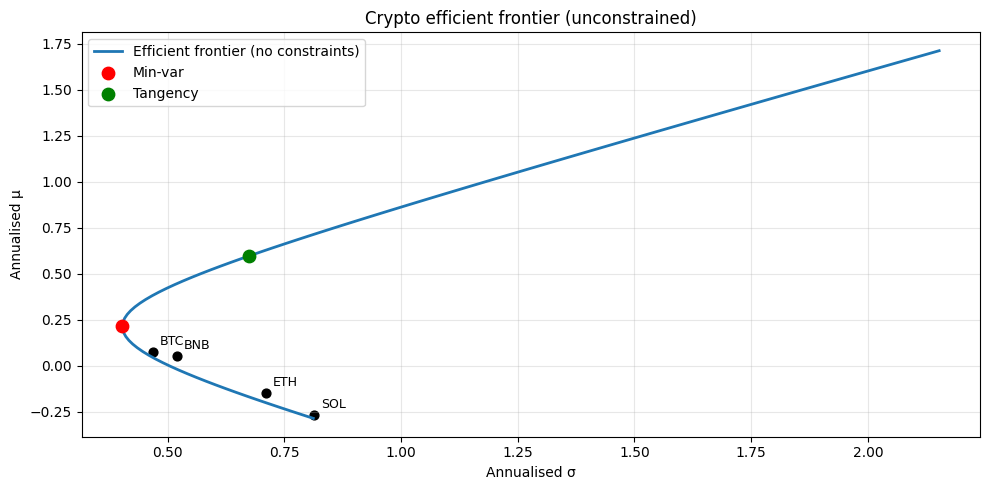

In [3]:
def minvar_for_target(mu, Sigma, target_mu):
    """Closed-form min-variance for target expected return."""
    n = len(mu)
    ones = np.ones(n)
    Sigma_inv = np.linalg.inv(Sigma)
    a = ones @ Sigma_inv @ ones
    b = ones @ Sigma_inv @ mu
    c = mu @ Sigma_inv @ mu
    d = a*c - b**2

    lam1 = (a * target_mu - b) / d
    lam2 = (c - b * target_mu) / d
    w = Sigma_inv @ (lam1 * mu + lam2 * ones)
    return w


# Trace the frontier
target_grid = np.linspace(mu_minvar - 0.5, max(mu_minvar + 1.5, mu_tan + 0.5), 100)
frontier_sigma = []
frontier_mu = []
for tgt in target_grid:
    w = minvar_for_target(mu, Sigma, tgt)
    sig = np.sqrt(w @ Sigma @ w)
    frontier_sigma.append(sig)
    frontier_mu.append(tgt)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(frontier_sigma, frontier_mu, '-', label='Efficient frontier (no constraints)', lw=2)
ax.scatter(sig_minvar, mu_minvar, color='red', s=80, label='Min-var', zorder=5)
ax.scatter(sig_tan, mu_tan, color='green', s=80, label='Tangency', zorder=5)
for s, m, name in zip(sigma_ann, mu_ann, daily.columns):
    ax.scatter(s, m, color='black', s=40)
    ax.annotate(name, (s, m), fontsize=9, xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Annualised σ'); ax.set_ylabel('Annualised μ')
ax.set_title('Crypto efficient frontier (unconstrained)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Capital allocation line through tangency
sigma_grid = np.linspace(0, sig_tan*2, 50)
cal_mu = r_f + (mu_tan - r_f) / sig_tan * sigma_grid

## Constraints — long-only, max-position

Real portfolios have constraints:
- **Long-only**: $w_i \ge 0$ for all $i$ (no shorting)
- **Position limits**: $w_i \le 0.5$ (concentration cap)
- **Sector limits**: aggregate weights by sector ≤ X%

These don't have closed forms — use **quadratic programming** via `scipy.optimize.minimize` with constraints.

In [4]:
def minvar_constrained(mu, Sigma, target_mu=None, long_only=True, max_position=None):
    n = len(mu)
    objective = lambda w: w @ Sigma @ w
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    if target_mu is not None:
        constraints.append({'type': 'eq', 'fun': lambda w: w @ mu - target_mu})

    if long_only:
        bounds = [(0, max_position) for _ in range(n)] if max_position else [(0, 1) for _ in range(n)]
    else:
        bounds = [(-1, 1) for _ in range(n)]

    res = minimize(objective, x0=np.ones(n)/n, constraints=constraints, bounds=bounds, method='SLSQP')
    return res.x


# Long-only min-variance
w_lo = minvar_constrained(mu, Sigma, target_mu=None, long_only=True)
sig_lo = np.sqrt(w_lo @ Sigma @ w_lo)

# Long-only tangency (max Sharpe via grid search over targets)
target_grid_lo = np.linspace(mu.min(), mu.max(), 100)
best_sharpe = -np.inf; best_w = None
for tgt in target_grid_lo:
    try:
        w = minvar_constrained(mu, Sigma, target_mu=tgt, long_only=True)
        sig = np.sqrt(w @ Sigma @ w)
        sh = (w @ mu - r_f) / sig
        if sh > best_sharpe:
            best_sharpe = sh; best_w = w; best_sig = sig; best_mu = w @ mu
    except: pass

print('Long-only min-variance:')
for s, w in zip(daily.columns, w_lo):
    print(f'  {s}: {w:.4f}')
print(f'  σ_p = {sig_lo:.4f}\n')

print('Long-only tangency:')
for s, w in zip(daily.columns, best_w):
    print(f'  {s}: {w:.4f}')
print(f'  μ_p = {best_mu:.4f}, σ_p = {best_sig:.4f}, Sharpe = {best_sharpe:.4f}\n')

print(f'Sharpe drop from unconstrained → long-only: {sharpe_tan:.3f} → {best_sharpe:.3f}')

Long-only min-variance:
  BNB: 0.3174
  BTC: 0.6826
  ETH: 0.0000
  SOL: 0.0000
  σ_p = 0.4526

Long-only tangency:
  BNB: 0.0000
  BTC: 1.0000
  ETH: 0.0000
  SOL: 0.0000
  μ_p = 0.0745, σ_p = 0.4681, Sharpe = 0.1592

Sharpe drop from unconstrained → long-only: 0.885 → 0.159


## The instability of MV

MV is notoriously sensitive to the inputs. The covariance matrix is estimated from data — small estimation errors blow up the optimised weights. Demonstrate by perturbing the mean returns slightly.

In [5]:
# Sensitivity: bump each μ_i by ±2% and recompute tangency weights
n_sims = 100
rng = np.random.default_rng(42)
weights_perturbed = []
for _ in range(n_sims):
    mu_p = mu * (1 + 0.02 * rng.standard_normal(n))
    excess = mu_p - r_f
    w_p = Sigma_inv @ excess / (ones @ Sigma_inv @ excess)
    weights_perturbed.append(w_p)
weights_perturbed = np.array(weights_perturbed)

print('Range of unconstrained tangency weights under ±2% μ perturbations:')
for i, s in enumerate(daily.columns):
    print(f'  {s}: μ {mu[i]:+.3f}, weight range [{weights_perturbed[:,i].min():+.3f}, {weights_perturbed[:,i].max():+.3f}]')

print('\n→ 2% input perturbation can swing weights by 100%+ — classic MV instability.')
print('→ Black-Litterman, shrinkage covariance, and L1/L2 regularisation all aim to fix this.')

Range of unconstrained tangency weights under ±2% μ perturbations:
  BNB: μ +0.054, weight range [+0.707, +0.756]
  BTC: μ +0.075, weight range [+2.126, +2.175]
  ETH: μ -0.148, weight range [-0.923, -0.840]
  SOL: μ -0.266, weight range [-1.035, -0.969]

→ 2% input perturbation can swing weights by 100%+ — classic MV instability.
→ Black-Litterman, shrinkage covariance, and L1/L2 regularisation all aim to fix this.


## Exercises

### Exercise 1 — Two-asset min-variance by hand

Derive the min-variance weights for a 2-asset portfolio with $\sigma_1, \sigma_2, \rho$. Verify numerically with the function above on BTC and ETH only.

In [6]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
idx = [list(daily.columns).index('BTC'), list(daily.columns).index('ETH')]
mu_2 = mu[idx]
Sigma_2 = Sigma[np.ix_(idx, idx)]
w_2 = minvar_constrained(mu_2, Sigma_2, target_mu=None, long_only=False)

# Closed form: w_BTC = (σ_E² - ρ σ_B σ_E) / (σ_B² + σ_E² - 2ρ σ_B σ_E)
sB = np.sqrt(Sigma_2[0,0]); sE = np.sqrt(Sigma_2[1,1])
rho = Sigma_2[0,1] / (sB * sE)
w_btc_cf = (sE**2 - rho*sB*sE) / (sB**2 + sE**2 - 2*rho*sB*sE)

print(f'σ_BTC = {sB:.4f}, σ_ETH = {sE:.4f}, ρ = {rho:.4f}')
print(f'Closed form  w_BTC: {w_btc_cf:.4f}')
print(f'Optimised    w_BTC: {w_2[0]:.4f}')
```

_Both should agree._

</details>

### Exercise 2 — Position-limit cost

Compute the long-only tangency portfolio with max position 30%. How much Sharpe is lost vs unconstrained tangency?

In [7]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
def tangency_constrained(mu, Sigma, max_pos):
    target_grid = np.linspace(mu.min(), mu.max()*1.2, 60)
    best_sh = -np.inf; best_w = None
    for tgt in target_grid:
        try:
            w = minvar_constrained(mu, Sigma, target_mu=tgt, long_only=True, max_position=max_pos)
            sig = np.sqrt(w @ Sigma @ w)
            sh = (w @ mu) / sig
            if sh > best_sh:
                best_sh = sh; best_w = w
        except: pass
    return best_w, best_sh

w_30, sh_30 = tangency_constrained(mu, Sigma, max_pos=0.30)
print(f'Max-30% long-only Sharpe: {sh_30:.4f}')
print(f'Long-only no max:         {best_sharpe:.4f}')
print(f'Unconstrained:            {sharpe_tan:.4f}')
```

_Each tighter constraint reduces Sharpe._

</details>

### Exercise 3 — Equal-weight vs optimised

Compare the equal-weight (1/N) Sharpe to the long-only tangency Sharpe. The 1/N rule was famously a strong baseline (DeMiguel-Garlappi-Uppal 2009).

In [8]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
w_eq = np.ones(n) / n
mu_eq = w_eq @ mu
sig_eq = np.sqrt(w_eq @ Sigma @ w_eq)
sh_eq = mu_eq / sig_eq
print(f'1/N portfolio: Sharpe = {sh_eq:.4f}')
print(f'Long-only tangency:    {best_sharpe:.4f}')
print(f'\n→ 1/N is robust because it doesn\'t use noisy μ estimates. Often beats optimised in OOS.')
```

_1/N often beats MV in out-of-sample; key insight in modern portfolio theory._

</details>

## Interview Q&A

**Q: State the MV problem.**

A: Given $\mu$, $\Sigma$, find $w$ that minimises $w^T \Sigma w$ subject to $w^T \mathbf{1} = 1$ and (optionally) $w^T \mu = \mu^*$. The locus of solutions across $\mu^*$ is the efficient frontier.

**Q: Closed-form for the unconstrained min-variance portfolio?**

A: $w_{MV} = \Sigma^{-1} \mathbf{1} / (\mathbf{1}^T \Sigma^{-1} \mathbf{1})$. No mean-return targeting — pure variance minimisation.

**Q: What's the tangency portfolio?**

A: The portfolio with the highest Sharpe ratio along the frontier. Closed form: $w_T = \Sigma^{-1}(\mu - r_f \mathbf{1}) / (\mathbf{1}^T \Sigma^{-1}(\mu - r_f \mathbf{1}))$. Under CAPM assumptions (mean-variance investors, single risk-free rate), every investor holds the tangency + cash → tangency = market portfolio.

**Q: Why is MV unstable?**

A: Two reasons. (1) **Estimation error in $\mu$**: small changes in expected returns shift the optimum by orders of magnitude (corner solutions). (2) **Estimation error in $\Sigma$**: noisy correlations magnified by the inversion $\Sigma^{-1}$. Solutions: shrinkage covariance (Ledoit-Wolf), Black-Litterman (Bayesian update), or just use 1/N (DeMiguel-Garlappi-Uppal 2009 showed this often beats optimised OOS).

**Q: Why are corner solutions a problem?**

A: With small estimation errors, weights flip from large positive to large negative on noise. Real PMs don't accept this — they want stable, intuitive allocations. Corner solutions also violate diversification preferences and trigger turnover costs.

**Q: 1/N portfolio — when does it beat MV?**

A: When estimation error in inputs dominates the theoretical gain from optimisation. Empirically: most of the time, especially with N small (4-30 assets) and short estimation samples (<5 years). Sharpe of 1/N is typically within 90% of the optimal-Sharpe oracle.

**Q: What's "shrinkage"?**

A: Replace the sample covariance $\hat \Sigma$ with a convex combination $\bar \Sigma = (1-\lambda) \hat \Sigma + \lambda T$ where $T$ is a structured target (e.g., diagonal or constant-correlation). $\lambda$ chosen via Stein-style optimal shrinkage. Reduces estimation error in $\Sigma^{-1}$, stabilising weights. Ledoit-Wolf 2004 is the canonical reference.

**Q: Black-Litterman — what does it do?**

A: Combines investor views with the market-implied "neutral" returns (from CAPM-implied returns at current weights). Outputs a posterior $\mu$ that's stable AND incorporates beliefs. Solves the input-instability problem of MV. Used by every multi-asset shop. See `02_black_litterman.ipynb`.

## Pitfalls reference card

| Pitfall | Issue | Fix |
|---|---|---|
| Using sample covariance directly | Noisy, ill-conditioned for $N$ close to sample size | Ledoit-Wolf shrinkage; reduce dimensions via factor model |
| Sample mean for μ | Mean is the noisiest moment; estimation error dominates | Black-Litterman; or use 1/N or risk parity |
| Annualisation by $\sqrt{T}$ blindly | Assumes IID — ignores autocorrelation, fat tails | OK for daily-aggregate equity but wrong for HF and credit |
| Forgetting transaction costs | Rebalancing to optimum is expensive | Add turnover penalty: $\min w^T \Sigma w + \tau \|w - w_{prev}\|_1$ |
| Ignoring covariance lookback | Trailing 1-year covariance vs 5-year — different optima | Match sample window to expected portfolio rebalance horizon |
| Long-short with leverage > 1 | Total gross exposure can exceed 100% even with $\sum w_i = 1$ | Add gross-exposure constraint $\sum |w_i| \le L$ |
| Missing fat tails | MV uses variance only — ignores tail risk | Use CVaR-optimisation or risk parity |

## What you've earned

After this notebook you can:

1. **State and solve** the MV problem in closed form for the unconstrained min-variance and tangency portfolios.
2. **Trace** the efficient frontier and identify the min-var and tangency points.
3. **Add** long-only and position-limit constraints via SLSQP.
4. **Demonstrate** MV's input sensitivity ("garbage-in garbage-out").
5. **Compare** 1/N to optimised — and explain why 1/N often beats MV out of sample.
6. **Defend** Black-Litterman, shrinkage, and risk parity as fixes for MV's instability.

This completes **Tier 1 of the curriculum** — Black-Scholes + extensions, Greeks, binomial trees, Monte Carlo, IV surface, VaR, ES, bond pricing, duration, Markowitz. Tier 2 picks up with stochastic vol, term structure, credit, factor models, and pairs trading.